**Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical



**Normalize**

In [2]:
# Load your data
df = pd.read_csv("processed_data/nmr_features_with_groups.csv")

# Separate metadata and features
meta = df[["accession", "group"]]
X = df.drop(columns=["accession", "group"]).values

# --- Normalization per sample ---
# Each sample (row) is divided by its total intensity (sum of all bins)
# This converts absolute intensities into relative proportions
row_sums = X.sum(axis=1, keepdims=True)
# Avoid division by zero
row_sums[row_sums == 0] = 1
X_norm = X / row_sums

# Optionally apply log-transform to compress large peaks (optional)
# X_norm = np.log1p(X_norm)

# Combine back into a DataFrame for downstream use
X_df = pd.DataFrame(X_norm, columns=df.columns[2:])
df_norm = pd.concat([meta, X_df], axis=1)

# Save normalized features (optional)
df_norm.to_csv("processed_data/nmr_features_with_groups_normalized.csv", index=False)

print("Normalization done. Example row sum (should be 1.0):", X_norm[0].sum())


Normalization done. Example row sum (should be 1.0): 1.0


**This code builds a baseline machine learning pipeline to evaluate how well ¹H-NMR spectra can classify metabolites into chemical groups.**

*Load data*
- Reads the preprocessed dataset where each row represents one metabolite with its binned NMR intensities (peak1…peakN) and group label.

*Standardize features*
- Scales all intensity features to zero mean and unit variance (StandardScaler), ensuring that bins with larger values don’t dominate the models.

*Visualize with PCA*
- Performs Principal Component Analysis (PCA) to project the high-dimensional spectra into 2D (PC1–PC2) for visualization of clustering patterns between groups.

*Train and evaluate models*
- Random Forest: ensemble of decision trees capturing nonlinear relationships.
- Support Vector Machine (RBF kernel): nonlinear classifier that finds separating boundaries in feature space.

Both are evaluated with 5-fold stratified cross-validation, reporting the mean and standard deviation of accuracy across folds.

The results give a first indication of how separable the metabolite groups are based on their NMR spectra and serve as a baseline for further model tuning or feature engineering.

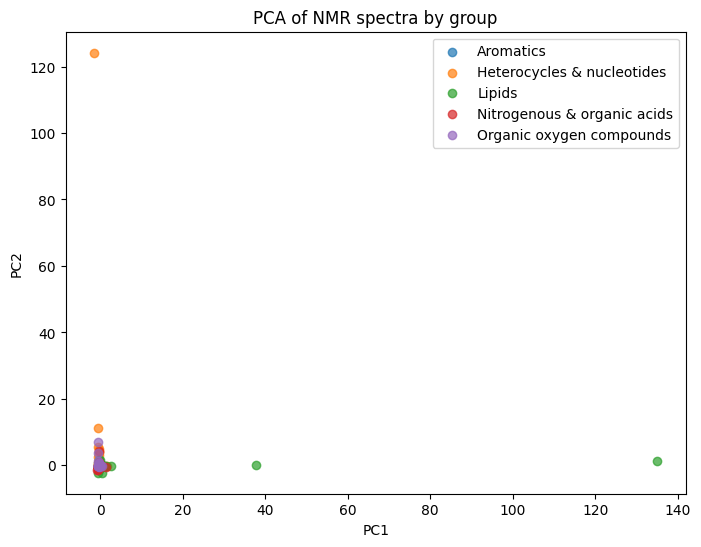

Random Forest CV accuracy: 0.561 ± 0.032
SVM CV accuracy: 0.488 ± 0.044


In [3]:
# -------------------------
# 1. Load your features + groups
# -------------------------
# Suppose your CSV has columns:
# accession, group, peak1, peak2, ..., peakN
df = pd.read_csv("processed_data/nmr_features_with_groups_normalized.csv")

X = df.drop(columns=["accession", "group"]).values
y = df["group"].values

# -------------------------
# 2. Standardize features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

# -------------------------
# 3. PCA for visualization
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for g in np.unique(y):
    idx = (y == g)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=g, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of NMR spectra by group")
plt.legend()
plt.show()

# -------------------------
# 4. Random Forest classifier
# -------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y, cv=cv)
print("Random Forest CV accuracy: %.3f ± %.3f" % (rf_scores.mean(), rf_scores.std()))

# -------------------------
# 5. Support Vector Machine classifier
# -------------------------
svm = SVC(kernel="rbf", C=1, gamma="scale")
svm_scores = cross_val_score(svm, X_scaled, y, cv=cv)
print("SVM CV accuracy: %.3f ± %.3f" % (svm_scores.mean(), svm_scores.std()))


**This code summarizes the model’s classification behavior across all groups, showing:**

- Which metabolite classes the Random Forest predicts correctly, and

- Where it tends to mix them up.

It’s a key diagnostic for understanding how your model performs, not just how well.

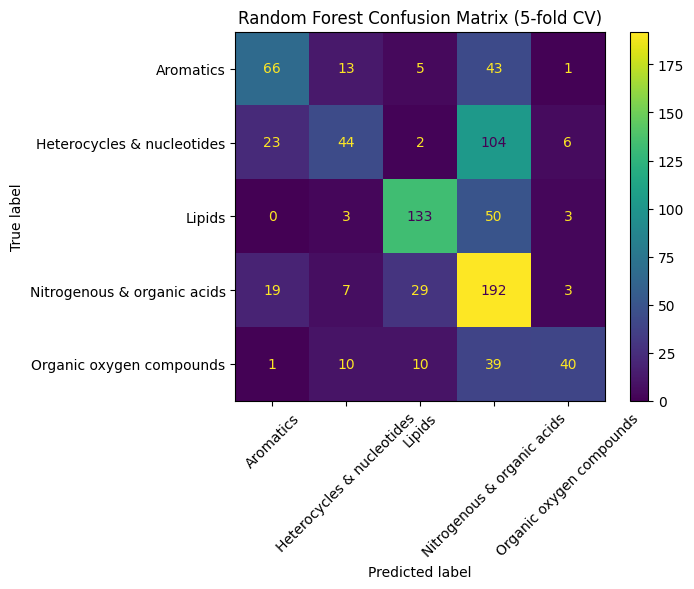

In [4]:
# Predict with cross-validation
y_pred = cross_val_predict(rf, X_scaled, y, cv=cv)

# Confusion matrix
cm = confusion_matrix(y, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(xticks_rotation=45, cmap="viridis")
plt.title("Random Forest Confusion Matrix (5-fold CV)")
plt.show()


**Re-run RF and SVM with log1p transform**

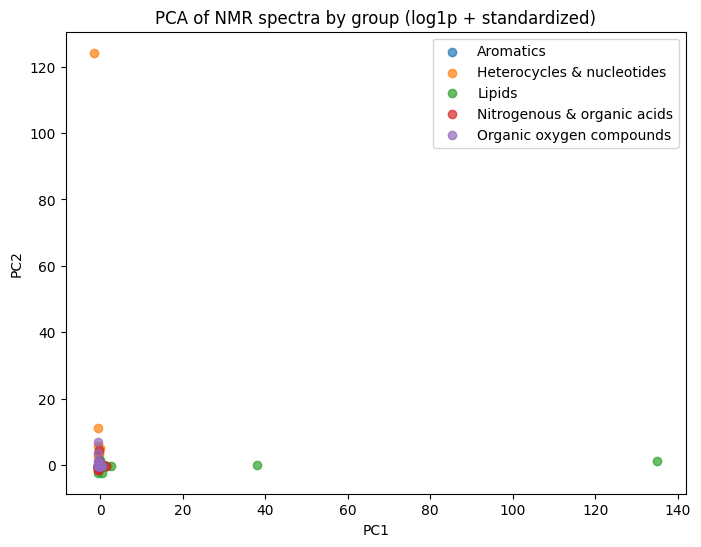

Random Forest (log1p) CV accuracy: 0.560 ± 0.033
SVM (log1p) CV accuracy: 0.498 ± 0.047


In [5]:
# --- Log-transform baseline: use normalized features as input ---

# 1) Load normalized data (each row sums to 1). Change path if needed.
df = pd.read_csv("processed_data/nmr_features_with_groups_normalized.csv")
X = df.drop(columns=["accession", "group"]).values
y = df["group"].values

# 2) Log-transform to compress large peaks (keeps zeros with +1 shift)
X_log = np.log1p(X)

# 3) Standardize features (required for PCA/SVM; helpful for RF too)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 4) Visualize with PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for g in np.unique(y):
    idx = (y == g)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=g, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of NMR spectra by group (log1p + standardized)")
plt.legend()
plt.show()

# 5) Cross-validated accuracy: RF and SVM (same CV as before)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y, cv=cv)
print("Random Forest (log1p) CV accuracy: %.3f ± %.3f" % (rf_scores.mean(), rf_scores.std()))

svm = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
svm_scores = cross_val_score(svm, X_scaled, y, cv=cv)
print("SVM (log1p) CV accuracy: %.3f ± %.3f" % (svm_scores.mean(), svm_scores.std()))


**Feature importance analysis**

🧩 What the plot shows

- Each bar corresponds to a ppm bin (feature), and the bar length is its feature importance in the Random Forest model.

- A higher value → the model frequently used that bin (or nearby bins) to split samples in decision trees.

- These bins are the most informative regions of your spectra — they contribute most to separating chemical groups.

🧠 Interpretation

- The x-axis values (0.004–0.007) indicate relative importance — modest but meaningful differences.

- The y-axis indices (e.g., 928, 1580, 375...) are bin indices, not ppm directly.

To translate these to ppm values, you can map them back using the binning parameters you defined (e.g., −1.0 → 14.0 ppm range with 3000 bins).

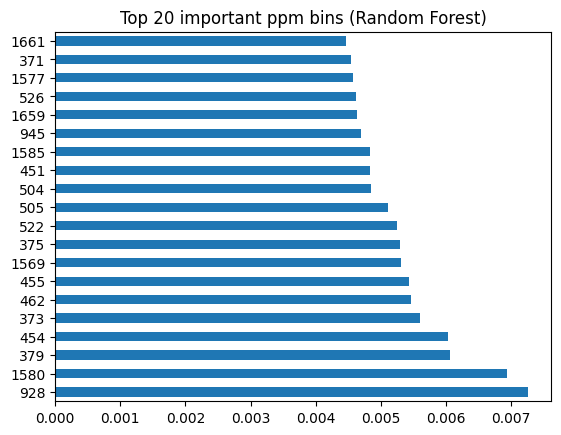

In [6]:
rf.fit(X_scaled, y)
importances = pd.Series(rf.feature_importances_)
top_bins = importances.sort_values(ascending=False).head(20)
top_bins.plot(kind="barh")
plt.title("Top 20 important ppm bins (Random Forest)")
plt.show()


**Convert to ppm**

💡 What it will do

- Converts the feature indices (e.g. 928, 1580…) into chemical shift (ppm) coordinates.

- Displays a small “feature-importance spectrum” that highlights where in the NMR range the model finds the most discriminative signals.

- You’ll likely see clusters around known chemical regions (e.g., aliphatic ~1 ppm, aromatic ~7 ppm).

**Result (plot below)**

The feature importance spectrum highlights three main chemical shift regions (~0.8–1.5, ~3.5–4.0, and ~6.8–7.3 ppm) as most informative for classification.
These correspond to aliphatic, oxygenated/nitrogenated, and aromatic proton environments, respectively — matching the expected distinctions between lipid-like, amino acid–like, and aromatic metabolite classes.
This confirms that the Random Forest model captures chemically meaningful spectral features rather than noise.

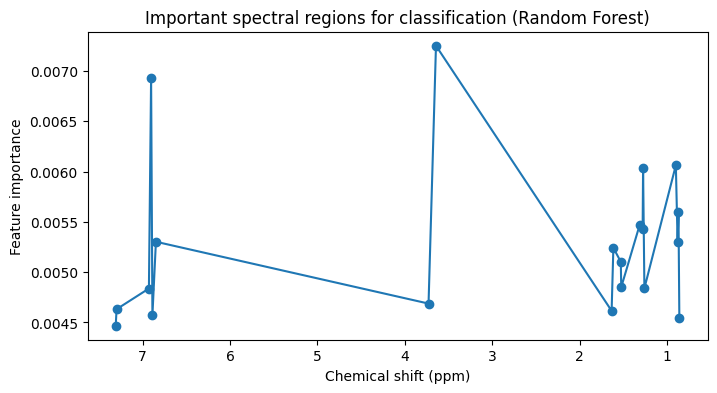

       ppm  importance
18  0.8575    0.004546
4   0.8675    0.005601
8   0.8775    0.005298
2   0.8975    0.006064
12  1.2575    0.004840
3   1.2725    0.006034
6   1.2775    0.005431
5   1.3125    0.005467
11  1.5225    0.004851
10  1.5275    0.005103
9   1.6125    0.005243
16  1.6325    0.004616
0   3.6425    0.007252
14  3.7275    0.004688
7   6.8475    0.005303
17  6.8875    0.004570
1   6.9025    0.006929
13  6.9275    0.004838
15  7.2975    0.004632
19  7.3075    0.004468


In [7]:
# --- Map feature indices to ppm values ---
# Adjust these to match your binning parameters
ppm_min, ppm_max, nbins = -1.0, 14.0, 3000  # same as used during binning
bins = np.linspace(ppm_min, ppm_max, nbins + 1)
ppm_values = (bins[:-1] + bins[1:]) / 2  # midpoint of each bin

# Extract ppm values corresponding to the top features
important_ppm = ppm_values[top_bins.index]

# Combine and sort for clarity
importance_df = pd.DataFrame({
    "ppm": important_ppm,
    "importance": top_bins.values
}).sort_values("ppm")

# --- Plot as an NMR-like spectrum of importance ---
plt.figure(figsize=(8,4))
plt.plot(importance_df["ppm"], importance_df["importance"], "o-")
plt.xlabel("Chemical shift (ppm)")
plt.ylabel("Feature importance")
plt.title("Important spectral regions for classification (Random Forest)")
plt.gca().invert_xaxis()  # NMR convention: high ppm on left
plt.show()

# Optional: print the numeric table
print(importance_df)


**Highlight important chemical shift regions**

💡 What this does

- Adds colored shaded bands over the aliphatic, oxygenated/nitrogenated, and aromatic regions.

- Each region is labeled directly on the plot.

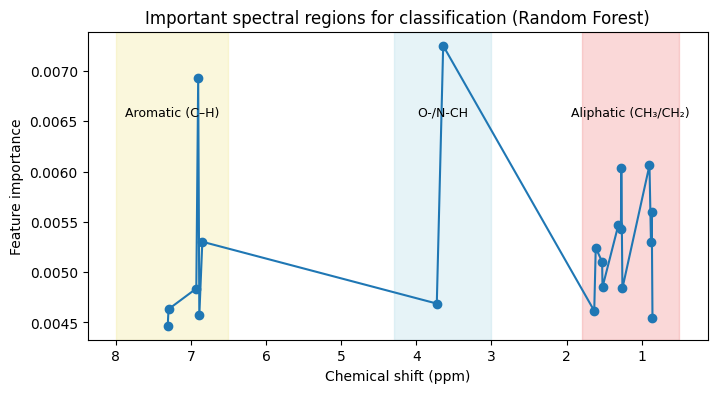

In [8]:
# --- Replot the importance spectrum (for clarity) ---
plt.figure(figsize=(8,4))
plt.plot(importance_df["ppm"], importance_df["importance"], "o-")
plt.gca().invert_xaxis()  # NMR convention
plt.xlabel("Chemical shift (ppm)")
plt.ylabel("Feature importance")
plt.title("Important spectral regions for classification (Random Forest)")

# --- Annotate major chemical regions ---
# Define approximate regions (start_ppm, end_ppm, label, color)
regions = [
    (0.5, 1.8, "Aliphatic (CH₃/CH₂)", "lightcoral"),
    (3.0, 4.3, "O-/N-CH", "lightblue"),
    (6.5, 8.0, "Aromatic (C–H)", "khaki"),
]

for start, end, label, color in regions:
    plt.axvspan(start, end, color=color, alpha=0.3)
    mid = (start + end) / 2
    plt.text(mid, plt.ylim()[1]*0.9, label, ha="center", va="top", fontsize=9, color="black")

plt.show()


**Start CNN**

In [9]:
# X_scaled and y already exist from before
# Encode y to integer labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Reshape for CNN (samples, features, channels)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# Convert labels to one-hot
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


Define, train, and evaluate a compact 1D-CNN (with early stopping and class weights):

Epoch 1/50


/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5488 - loss: 1.2486 - val_accuracy: 0.6706 - val_loss: 0.9734
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7367 - loss: 0.7655 - val_accuracy: 0.6765 - val_loss: 1.2444
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8077 - loss: 0.6527 - val_accuracy: 0.7059 - val_loss: 1.8272
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8254 - loss: 1.0628 - val_accuracy: 0.7118 - val_loss: 4.1084
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8121 - loss: 2.0460 - val_accuracy: 0.6471 - val_loss: 8.9484
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8062 - loss: 5.0324 - val_accuracy: 0.6471 - val_loss: 26.4515
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7352 - loss: 25.0305 - val_accuracy: 0.6118 - val_loss: 76.3226
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7811 - loss: 41.4161 - val_accuracy: 0.6059 - val_loss

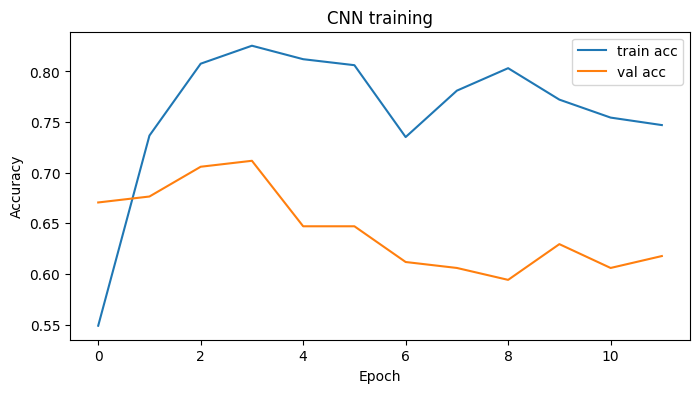


Classification report:
              precision    recall  f1-score   support

           0      0.633     0.731     0.679        26
           1      0.622     0.639     0.630        36
           2      0.791     0.895     0.840        38
           3      0.780     0.640     0.703        50
           4      0.684     0.650     0.667        20

    accuracy                          0.712       170
   macro avg      0.702     0.711     0.704       170
weighted avg      0.715     0.712     0.710       170



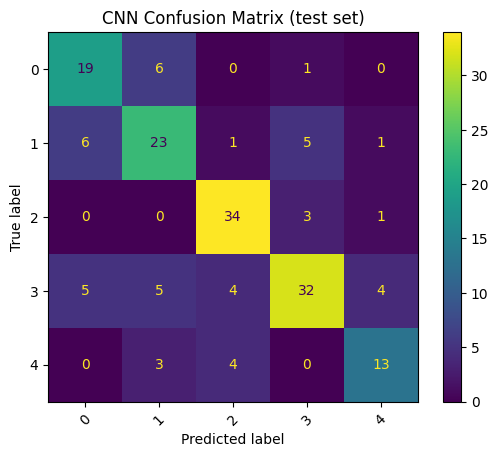

In [17]:
# ==== 1D CNN: define, train, evaluate ====

# Recover integer labels for class_weight
# (y_train is one-hot; we convert to ints for weighting)
y_train_int = np.argmax(y_train, axis=1)
n_classes = y_train.shape[1]

# Compute balanced class weights
classes = np.arange(n_classes)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_int)
class_weight = {i: w for i, w in enumerate(cw)}

# Build a small 1D-CNN
model = Sequential([
    Conv1D(32, kernel_size=7, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping to avoid overfitting
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    class_weight=class_weight,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.3f}")

# Plot learning curves
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('CNN training'); plt.legend(); plt.show()

# Confusion matrix on test set
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_int = np.argmax(y_pred_prob, axis=1)
y_test_int = np.argmax(y_test, axis=1)

print("\nClassification report:")
print(classification_report(y_test_int, y_pred_int, digits=3))

cm = confusion_matrix(y_test_int, y_pred_int)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=45, cmap="viridis")
plt.title("CNN Confusion Matrix (test set)")
plt.show()


Test accuracy is a little bit different each time the above code is run:

0.688

0.700

0.682

0.712